# EDA – Bank Credit Card Transactions (`creditcard.csv`)

**What this notebook covers (Task 1):**
1. Load and inspect the raw data
2. Remove 1,081 duplicate rows
3. Analyse the extreme class imbalance (0.17% fraud)
4. Explore transaction amount and time distributions
5. Identify PCA features most correlated with fraud
6. Save the cleaned dataset

**Dataset quick facts:**
| Item | Value |
|------|-------|
| Rows | 284,807 (→ 283,726 after dedup) |
| Columns | 31 |
| Features | Time, V1–V28 (PCA), Amount, Class |
| Missing values | None |
| Duplicates | **1,081** |
| Fraud rate | **0.17%** — EXTREME imbalance |

> `V1–V28` are anonymised via PCA for privacy — we cannot interpret them directly,
> but we can still identify which ones correlate most with fraud.

## 1. Setup & Imports

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.join('..'))
from src.preprocessing import class_distribution

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)

DATA_RAW       = os.path.join('..', 'data', 'raw')
DATA_PROCESSED = os.path.join('..', 'data', 'processed')
FIGURES_DIR    = 'figures'

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(DATA_PROCESSED, exist_ok=True)
print('✓ Setup complete')

✓ Setup complete


## 2. Load Data

In [2]:
cc = pd.read_csv(os.path.join(DATA_RAW, 'creditcard.csv'))
print(f"Shape: {cc.shape[0]:,} rows  x  {cc.shape[1]} columns")
cc.head()

Shape: 284,807 rows  x  31 columns


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


In [3]:
cc.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

**Column breakdown:**
- `Time` — seconds elapsed since the first transaction in the dataset (~48 hours of data)
- `V1–V28` — PCA-transformed features (anonymised for privacy)
- `Amount` — transaction amount in USD
- `Class` — **target**: 0 = legitimate, 1 = fraud

## 3. Data Cleaning

### 3.1 Missing Values

In [4]:
total_missing = cc.isnull().sum().sum()
print(f"Total missing values: {total_missing}")
# ► FINDING: No missing values. No imputation needed.

Total missing values: 0


### 3.2 Duplicate Rows

In [5]:
n_dupes = cc.duplicated().sum()
print(f"Duplicate rows found: {n_dupes:,}")

# ► FINDING: 1,081 duplicates.
# Why remove them?
#   1. They inflate transaction counts (misleads velocity calculations)
#   2. They can cause data leakage: the same row might end up in both
#      train AND test after splitting, making test metrics over-optimistic.

Duplicate rows found: 1,081


In [6]:
# .drop_duplicates(keep='first') keeps the first occurrence, drops the rest
cc = cc.drop_duplicates(keep='first').reset_index(drop=True)

print(f"Shape after removing duplicates: {cc.shape}")
print(f"Rows removed: {n_dupes:,}")

Shape after removing duplicates: (283726, 31)
Rows removed: 1,081


### 3.3 Summary Statistics

In [7]:
# Focus on Amount, Time, and Class — V1–V28 are PCA outputs and
# their raw statistics are less meaningful to interpret directly
cc[['Time', 'Amount', 'Class']].describe()

,Time,Amount,Class
count,283726.0000,283726.0000,283726.0000
mean,94811.0776,88.4727,0.0017
std,47481.0479,250.3994,0.0408
min,0.0000,0.0000,0.0000
25%,54204.7500,5.6000,0.0000
50%,84692.5000,22.0000,0.0000
75%,139298.0000,77.5100,0.0000
max,172792.0000,25691.1600,1.0000


**Key observations:**
- `Time` spans 0 to 172,792 seconds ≈ **48 hours** of data
- `Amount` is highly right-skewed: mean ≈ \$88 but median ≈ \$22 (most transactions are small)
- `Class` mean ≈ 0.0017 → only **0.17%** are fraud

## 4. Class Imbalance Analysis

In [8]:
print("=== CLASS DISTRIBUTION ===")
dist = class_distribution(cc, 'Class')

=== CLASS DISTRIBUTION ===
 class  count  percentage      label
     0 283253     99.8300 Legitimate
     1    473      0.1700      Fraud


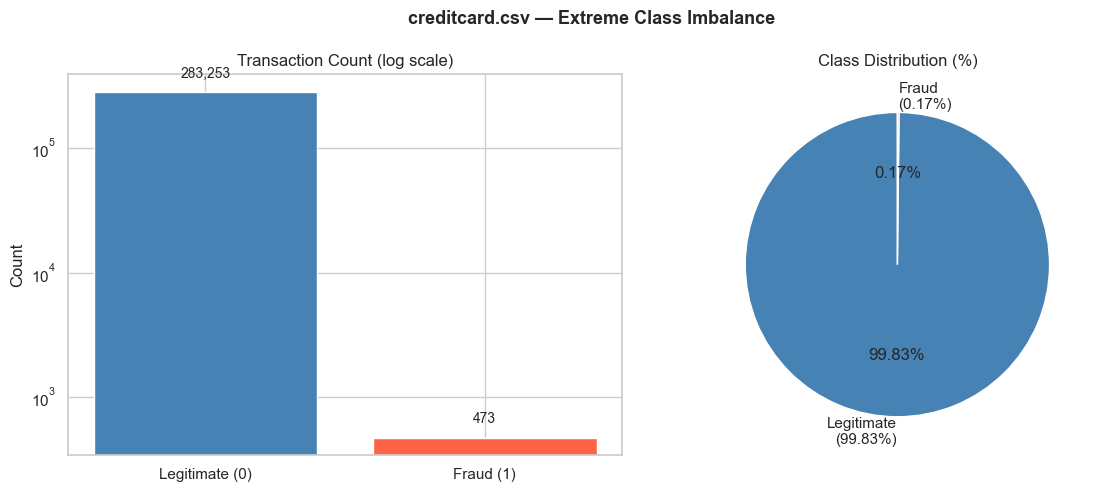


FINDING: 0.17% fraud rate — EXTREME imbalance (578:1 ratio).
SMOTE is essential. Even with SMOTE, evaluation must use AUC-PR not accuracy.


In [9]:
# The imbalance here is FAR more extreme than the e-commerce dataset.
# 284,315 legitimate vs 492 fraud = ratio of ~578:1.
# A model predicting "always legitimate" would score 99.83% accuracy
# but would catch ZERO fraud cases.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(
    ['Legitimate (0)', 'Fraud (1)'],
    dist['count'],
    color=['steelblue', 'tomato'],
    edgecolor='white'
)
axes[0].set_title('Transaction Count (log scale)')
axes[0].set_ylabel('Count')
axes[0].set_yscale('log')  # log scale — the gap is too large for linear scale
for i, v in enumerate(dist['count']):
    axes[0].text(i, v * 1.3, f"{v:,}", ha='center', fontsize=10)

axes[1].pie(
    dist['percentage'],
    labels=['Legitimate\n(99.83%)', 'Fraud\n(0.17%)'],
    autopct='%1.2f%%',
    colors=['steelblue', 'tomato'],
    startangle=90
)
axes[1].set_title('Class Distribution (%)')

plt.suptitle('creditcard.csv — Extreme Class Imbalance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'class_imbalance_creditcard.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\nFINDING: 0.17% fraud rate — EXTREME imbalance (578:1 ratio).")
print("SMOTE is essential. Even with SMOTE, evaluation must use AUC-PR not accuracy.")

## 5. Transaction Amount Analysis

### 5.1 Amount Distribution

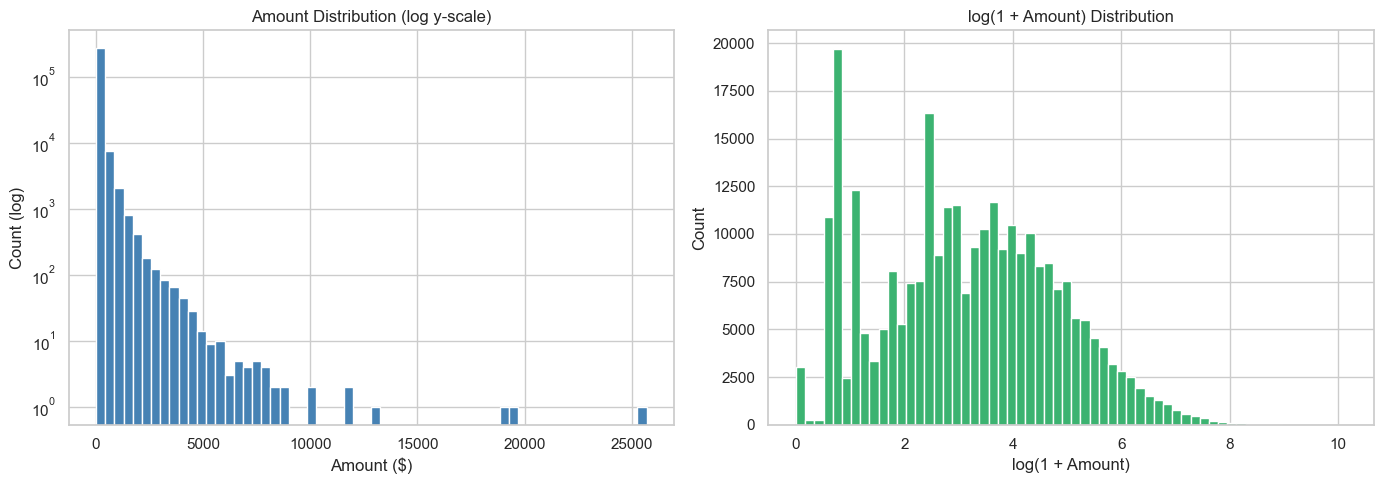

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw distribution — right-skewed (most transactions are small amounts)
axes[0].hist(cc['Amount'], bins=60, color='steelblue', edgecolor='white', log=True)
axes[0].set_title('Amount Distribution (log y-scale)')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Count (log)')

# Right: log-transform makes the shape clearer
# np.log1p(x) = log(1+x) — safe even when x=0 (avoids log(0) = -infinity)
axes[1].hist(np.log1p(cc['Amount']), bins=60, color='mediumseagreen', edgecolor='white')
axes[1].set_title('log(1 + Amount) Distribution')
axes[1].set_xlabel('log(1 + Amount)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'amount_dist_cc.png'), dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Amount by Class

C:\Users\gtta1\AppData\Local\Temp\ipykernel_17808\2372819132.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cc_plot, x='Class Label', y='Amount', palette=palette, ax=axes[0])


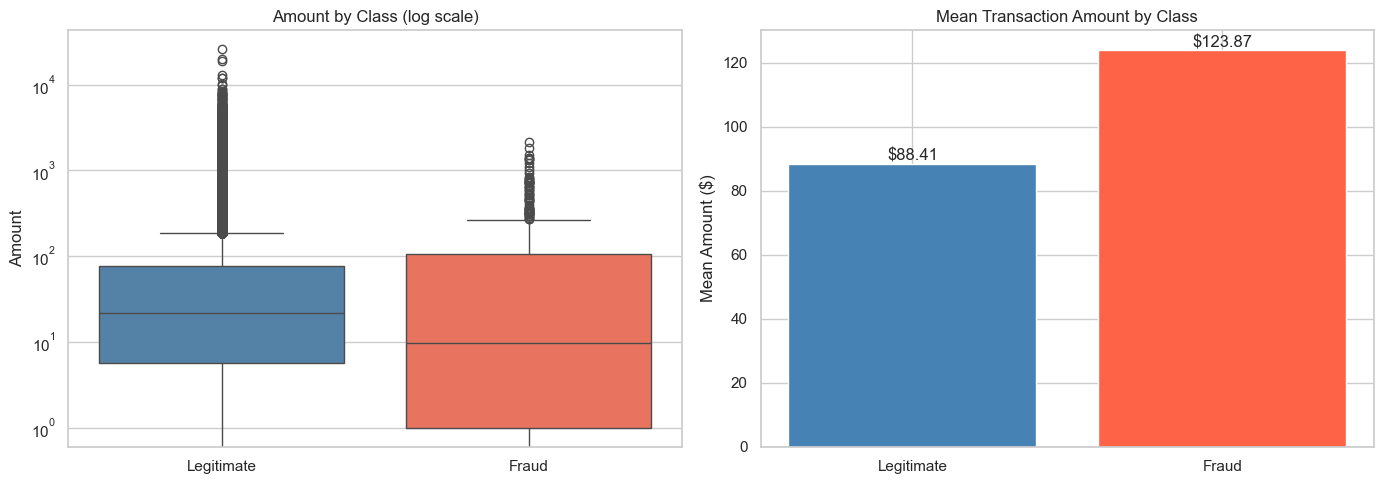

Mean amount — Legitimate: $88.41  |  Fraud: $123.87


In [11]:
cc_plot = cc.copy()
cc_plot['Class Label'] = cc_plot['Class'].map({0: 'Legitimate', 1: 'Fraud'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = {'Legitimate': 'steelblue', 'Fraud': 'tomato'}

sns.boxplot(data=cc_plot, x='Class Label', y='Amount', palette=palette, ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Amount by Class (log scale)')
axes[0].set_xlabel('')

mean_amounts = cc.groupby('Class')['Amount'].mean()
axes[1].bar(['Legitimate', 'Fraud'], mean_amounts.values,
            color=['steelblue', 'tomato'], edgecolor='white')
axes[1].set_title('Mean Transaction Amount by Class')
axes[1].set_ylabel('Mean Amount ($)')
for i, v in enumerate(mean_amounts.values):
    axes[1].text(i, v + 1, f"${v:.2f}", ha='center')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'amount_by_class_cc.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean amount — Legitimate: ${mean_amounts[0]:.2f}  |  Fraud: ${mean_amounts[1]:.2f}")

## 6. Time Feature Analysis

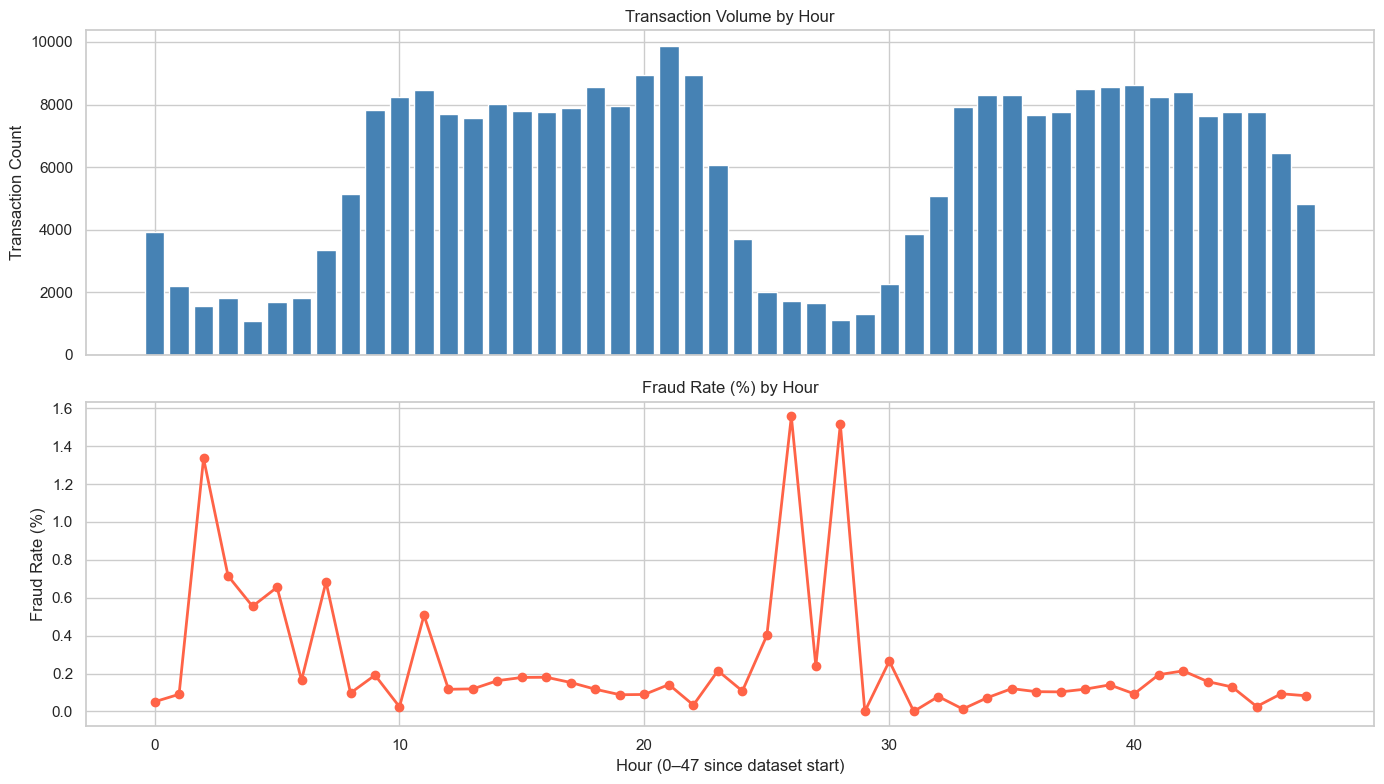

In [12]:
# Convert seconds → hour index (0–47) to see transaction patterns over 48 hours
cc['hour'] = (cc['Time'] // 3600).astype(int)

hourly = (
    cc.groupby('hour')['Class']
    .agg(total='count', fraud_count='sum')
    .assign(fraud_rate=lambda x: x['fraud_count'] / x['total'] * 100)
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].bar(hourly.index, hourly['total'], color='steelblue', edgecolor='white')
axes[0].set_title('Transaction Volume by Hour')
axes[0].set_ylabel('Transaction Count')

axes[1].plot(hourly.index, hourly['fraud_rate'], 'o-', color='tomato', linewidth=2)
axes[1].set_title('Fraud Rate (%) by Hour')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_xlabel('Hour (0–47 since dataset start)')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'time_analysis_cc.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Feature Correlation with Fraud (PCA Features)

Even though V1–V28 are anonymised, we can rank them by their **correlation with the fraud class**.
Higher absolute correlation = stronger fraud signal = more useful for modelling.

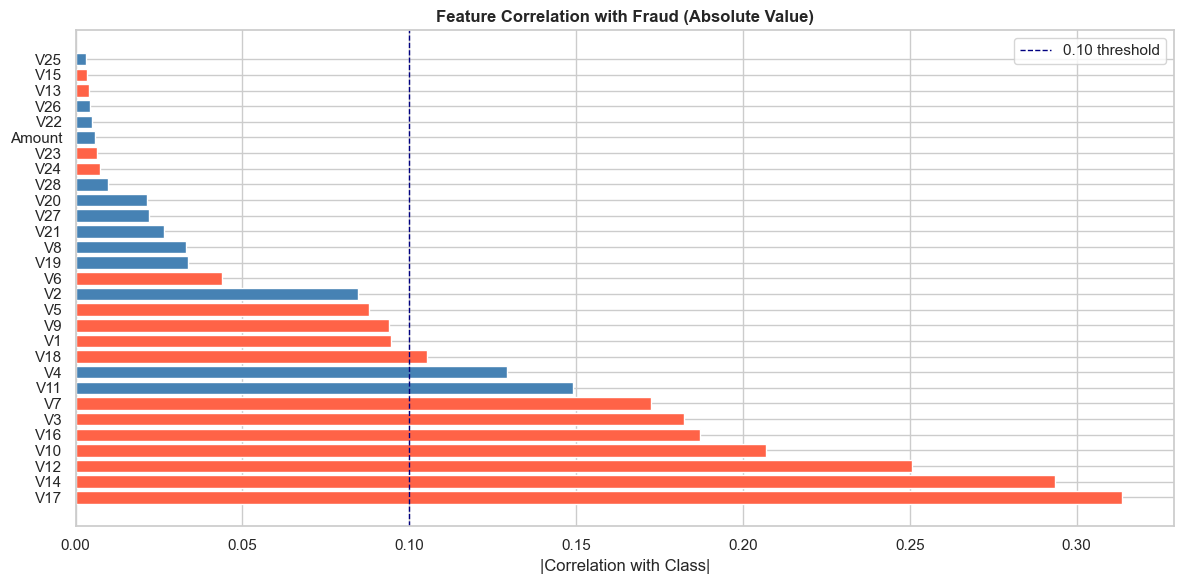

Top 10 features most correlated with fraud:
V17   0.3135
V14   0.2934
V12   0.2507
V10   0.2070
V16   0.1872
V3    0.1823
V7    0.1723
V11   0.1491
V4    0.1293
V18   0.1053


In [13]:
pca_cols = [f'V{i}' for i in range(1, 29)]
correlations = cc[pca_cols + ['Amount', 'Class']].corr()['Class'].drop('Class')

fig, ax = plt.subplots(figsize=(12, 6))
corr_sorted = correlations.abs().sort_values(ascending=False)
colors = ['tomato' if correlations[col] < 0 else 'steelblue' for col in corr_sorted.index]

ax.barh(corr_sorted.index, corr_sorted.values, color=colors, edgecolor='white')
ax.set_xlabel('|Correlation with Class|')
ax.set_title('Feature Correlation with Fraud (Absolute Value)', fontsize=12, fontweight='bold')
ax.axvline(0.1, color='navy', linestyle='--', linewidth=1, label='0.10 threshold')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'feature_correlation_cc.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 features most correlated with fraud:")
print(correlations.abs().sort_values(ascending=False).head(10).to_string())

## 8. Save Cleaned Data

In [14]:
# Drop the helper 'hour' column — it will be properly re-engineered
# with the correct formula in the feature engineering notebook
cc = cc.drop(columns=['hour'])

output_path = os.path.join(DATA_PROCESSED, 'creditcard_cleaned.csv')
cc.to_csv(output_path, index=False)

print(f"✓ Saved to: {output_path}")
print(f"   Shape  : {cc.shape}")

✓ Saved to: ..\data\processed\creditcard_cleaned.csv
   Shape  : (283726, 31)


## Summary of EDA Findings

| Finding | Detail |
|---------|--------|
| **Duplicates** | 1,081 rows removed |
| **Missing values** | None |
| **Class imbalance** | 0.17% fraud — extreme (578:1 ratio) |
| **Amount** | Right-skewed; fraud transactions tend to be smaller on average |
| **Time** | Transaction volume and fraud rate vary by hour |
| **Top features** | V14, V4, V11, V12 have highest correlation with fraud |
| **Accuracy trap** | Predicting "all legitimate" = 99.83% accuracy, 0% recall |
| **Next step** | Feature engineering → `feature_engineering.ipynb` |